### ВЛОЖЕННЫЕ ФУНКЦИИ

Функции, которые объявлены в теле других функций, называются вложенными.

In [2]:
# Объявляем внешнюю функцию outer()
def outer():
    # Печатаем информацию о вызове внешней функции
    print('Called outer function')
    # Объявляем внутреннюю функцию inner()
    def inner():
        # Печатаем информацию о вызове внутренней функции
        print('Called inner function')
    # Вызываем внутреннюю функцию inner()
    inner()

In [3]:
# Вызываем внешнюю функцию outer()    
outer()    
## Будет напечатано:
## Called outer function
## Called inner function

Called outer function
Called inner function


In [7]:
# Задаём внешнюю функцию
def print_root(value, n=2):
    # Задаём внутреннюю функцию
    # Она будет являться вспомогательной
    def root(value, n=2):
        result = value ** (1/n)
        return result
    # Получаем результат из внутренней функции
    res = root(value, n)
    # Печатаем результат и не возвращаем его
    print(f'Root of power {n} from {value} equals {res}')

In [8]:
print_root(81, 4)

Root of power 4 from 81 equals 3.0


В Python существует «право на владение» объектом — функцией или переменной. Если объект находится в некоторой функции, то не из каждой точки программы можно будет к нему обратиться.

Чтобы лучше понять, в каких частях программы можно обращаться к различным переменным и функциям, рассмотрим классификацию переменных и познакомимся с важными терминами — область видимости и разрешение переменных.

!!! Примечание. Функции, которые содержат внутри себя объявление других функций, часто называют объемлющими (enclosing). Например, функция print_root() из прошлого примера будет объемлющей для функции root().

### РАЗРЕШЕНИЕ ПЕРЕМЕННЫХ. ОБЛАСТИ ВИДИМОСТИ

Когда объявление переменной будет завершено, Python добавит её имя в так называемое пространство имён (namespace)

Разрешение — процесс поиска интерпретатором объекта, который скрывается за названием переменной.

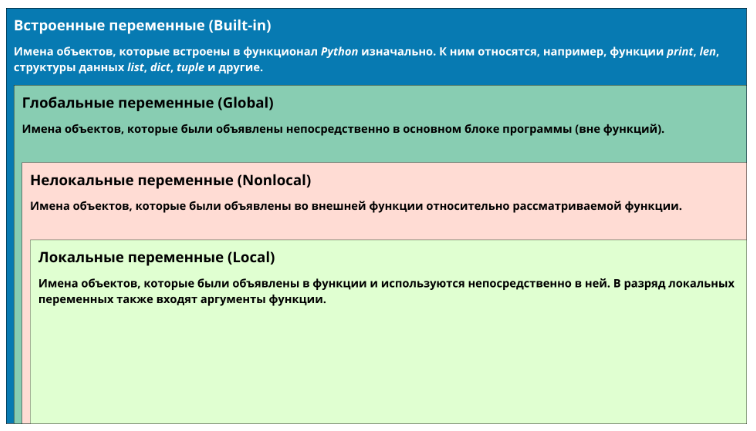

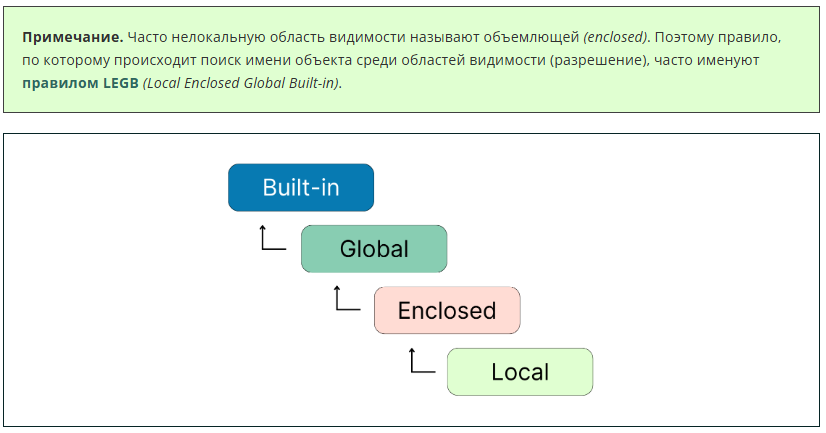

### Изменение переменных вне области видимости

Если в коде функции происходит переопределение глобальной или нелокальной переменной, то необходимо просто указать, что та или иная переменная является глобальной или нелокальной. Для этого используются ключевые слова global и nonlocal

Начнём с использования ключевого слова global и рассмотрим его синтаксис на простейшем примере.

Предположим, мы хотим реализовать процесс добавления товара на склад. Под добавлением мы можем понимать что угодно — например, добавление товара в базу данных. Сейчас это непринципиально. Также мы хотим хранить общее количество товаров на складе в виде глобальной переменной с именем global_count.

У нас есть функция add_item() — она реализует добавление товара в базу данных, а после увеличивает общее количество товаров на 1.

In [9]:
# Создадим глобальную переменную, изначально она равна 0
global_count = 0
 
# Создадим функцию, которая прибавляет 1 к переменной global_count
def add_item():
    # Здесь мог бы быть код для добавления товара в базу данных
    # Увеличим общее количество товаров на 1
    global_count = global_count + 1
 
# Вызовем функцию add_item()
add_item()
# Напечатаем значение переменной global_count
print(global_count)

UnboundLocalError: cannot access local variable 'global_count' where it is not associated with a value

Давайте исправим ошибку. Для этого добавим оператор global в функцию перед той переменной, которую хотим изменить глобально. Синтаксис выглядит следующим образом:

global <имя переменной>

In [10]:
# Создадим глобальную переменную, изначально она равна 0
global_count = 0
 
# Создадим функцию, которая прибавляет 1 к переменной global_count
def add_item():
    # Здесь мог бы быть код для добавления товара в базу данных
    
    # Укажем, что global_count является глобальной переменной
    global global_count 
    # Увеличим общее количество товаров на 1
    global_count = global_count + 1
 
# Вызовем функцию add_item()
add_item()
# Напечатаем значение переменной global_count
print(global_count)

1


Выражение global указывает на то, что, пока выполняется функция add_item(), ссылки на имя global_count будут вести к переменной global_count, объявленной в глобальной области видимости.

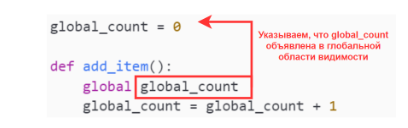

!!!!!!!!!! Примечание. Объявление глобальной переменной в функции с помощью global должно идти раньше, чем эта переменная будет использоваться. Попробуйте самостоятельно поменять местами строки с объявлением global и изменением переменной global_count. Вы получите ту же ошибку, что и раньше.

In [11]:
# Создаём функцию, которая прибавляет 1 к переменной global_count
def add_item():
    # Здесь мог бы быть код для добавления товара в базу данных
    # Указываем, что global_count является глобальной переменной
    global global_count
    # Инициализируем глобальную переменную прямо внутри функции 
    global_count = 0
    # Увеличиваем общее количество товаров на 1
    global_count = global_count + 1

# Вызываем функцию add_item()
add_item()
# Напечатаем значение переменной global_count
print(global_count)

1


!!!!!!!!!!!!!!!!!!! Важно отметить: несмотря на то что объявление переменной global_count и находится внутри функции, благодаря объявлению global эта переменная была создана именно в глобальном пространстве имён. Поэтому переменная не уничтожается по завершении работы функции и мы можем к ней обращаться из любой части программы.

Важно! Несмотря на то что в Python предусмотрена возможность объявлять и изменять глобальные переменные внутри функций, стандарты разработки на Python крайне не рекомендуют этого делать.

С ростом программы растёт количество переменных, и, если они все будут глобальными и будут изменяться в разных частях кода, может наступить настоящий хаос. Отлаживать такие программы чрезвычайно трудно.

Хорошей практикой считается создание переменных, доступных для изменения только в той области, где это действительно необходимо. Вместо использования global лучше передавать данные через аргументы и возвращать через return.

## ИЗМЕНЕНИЕ ЗНАЧЕНИЙ НЕЛОКАЛЬНЫХ ПЕРЕМЕННЫХ. ОБЪЯВЛЕНИЕ NONLOCAL

Для примера создадим функцию inner(), которая использует переменную enclosing_count, созданную во внешней функции outer(). Она также должна увеличить значение этой переменной на 1 и сразу напечатать её значение. Всё, как в прошлой задаче, но теперь переменная является нелокальной.

In [12]:
# Внешняя функция
def outer():
    # Создадим переменную, относящуюся к внешней функции
    enclosing_count = 0
    # Внутренняя функция
    def inner():
        # Прибавим 1 к enclosing_count
        enclosing_count = enclosing_count + 1
        # Напечатаем значение enclosing_count
        print(enclosing_count)
    # Запустим внутреннюю функцию из внешней
    inner()
 
# Запустим внешнюю функцию
outer()

UnboundLocalError: cannot access local variable 'enclosing_count' where it is not associated with a value

Как и ожидалось, получаем ошибку. Причём ошибка того же характера: интерпретатор полагает, что enclosing_count — это локальная переменная, которая ещё не была объявлена. Принцип, по которому возникает эта ошибка, идентичен предыдущим примерам.

Чтобы указать интерпретатору, что мы хотим изменить значение именно нелокальной переменной, используется ключевое слово nonlocal. Имена, определённые после этого ключевого слова, ссылаются на переменные из ближайшей нелокальной (объемлющей) области видимости.

Добавим объявление nonlocal во внутреннюю функцию inner()

In [13]:
# Внешняя функция
def outer():
    # Создадим переменную, относящуюся к внешней функции
    enclosing_count = 0
    # Внутренняя функция
    def inner():
        # Укажем, что используем нелокальную переменную enclosing_count
        nonlocal enclosing_count
        # Прибавим 1 к enclosing_count
        enclosing_count = enclosing_count + 1
        # Напечатаем значение enclosing_count
        print(enclosing_count)
    # Запустим внутреннюю функцию из внешней
    inner()
 
# Запустим внешнюю функцию
outer()

1


После выражения nonlocal enclosing_count, когда inner() ссылается на enclosing_count, мы будем обращаться к enclosing_count в ближайшей объемлющей области, чьё определение дано внутри outer().

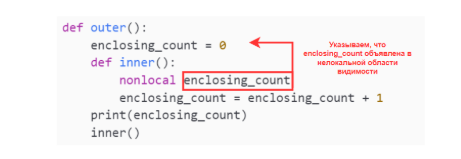

Представим, что у нас есть функция calculate_cost(), которая вычисляет стоимость товара с учётом скидки. Есть два параметра:

cost — стоимость товара, которая всегда является числом;
sale — скидка на товар, которая задаётся в виде дробного числа (например, 0.15 — скидка в 15 %).

In [14]:
# Функция для вычисления стоимости
# Аргументы — cost (стоимость), sale (размер скидки)
def calculate_cost(cost, sale):
    # Считаем итоговую стоимость и возвращаем её
    # (стоимость — стоимость * скидка)           
    return cost - cost * sale

Мы хотим модифицировать функцию так, чтобы параметр sale можно было задавать не только дробным числом, но и в процентах в виде целого числа или строки.

Следующие вызовы функции должны отрабатывать одинаково:

In [ ]:
print(calculate_cost(1330, '15%'))
print(calculate_cost(1330, 15))
print(calculate_cost(1330, 0.15))

Во всех случаях функция должна возвращать число 1130.5 независимо от того, как задаётся скидка.

В данном случае будет удобно написать внутреннюю вспомогательную функцию preprocessing_sale(), которая будет изменять значения аргумента sale следующим образом:

если аргумент — строка, мы будем удалять из неё символ %, приводить к типу данных float и делить на 100;
если аргумент — целое число, мы будем делить его на 100.
Аргумент функции также является локальной переменной по отношению к ней и нелокальной переменной по отношению ко внутренней функции. Поэтому для изменения аргумента нам необходимо будет объявить во внутренней функции, что мы используем нелокальную переменную sale.

Итоговый код будет выглядеть следующим образом:

In [16]:
# Внешняя функция для вычисления итоговой стоимости
def calculate_cost(cost, sale):
    # Внутренняя функция для предобработки аргумента sale
    def preprocessing_sale():
        # Объявляем, что используем нелокальную переменную sale
        nonlocal sale
        # Если sale — строка
        if type(sale) is str:
            # Удаляем из строки '%', приводим к float и делим на 100
            sale = float(sale.replace('%', '')) / 100
        # Если sale — целое число
        elif type(sale) is int:
            # Делим его на 100 
            sale = sale / 100
    # Запускаем предобработку, прежде чем вычислить стоимость
    preprocessing_sale()
    # Считаем итоговую стоимость и возвращаем её
    # (стоимость — стоимость * скидка)     
    return cost - cost * sale

In [17]:
print(calculate_cost(1330, '15%'))
print(calculate_cost(1330, 15))
print(calculate_cost(1330, 0.15))

1130.5
1130.5
1130.5


Всё работает так, как и задумывалось. Благодаря nonlocal мы изменяем значение аргумента sale, не затронув расчёт стоимости. Каждый раз, когда будет вызываться внешняя функция, сначала будет происходить предварительная обработка аргумента, и только потом сам расчёт стоимости.

** Мы реализуем функцию count_occurrences(), у которой есть два параметра s — строка и symbols — список из символов. Функция вычисляет, сколько раз символ symbol встречается в строке s.

Перед подсчётом количества символов строка s проходит предобработку: из неё удаляются пробелы, а символы приводятся к нижнему регистру.



In [ ]:
## Введите свое решение ниже

# Функция для вычисления количества символов (symbol) в строке s
def count_occurrences(s, symbol):
    # Внутренняя функция для предобработки строки s
    def preprocessing_s():
        # Удаляем пробелы из строки
        nonlocal s
        s = s.replace(' ', '')
        # Приводим строку к нижнему регистру
        s = s.lower()
    # Вызываем функцию для предобработки аргумента s
    preprocessing_s()
    # Считаем количество символов symbol в строке s и возвращаем результат
    return s.count(symbol)

count_occurrences('This is simple string', symbol='t')



2

### ИЗМЕНЕНИЕ ЗНАЧЕНИЙ ВСТРОЕННЫХ ПЕРЕМЕННЫХ

 Старайтесь никогда не переопределять имена встроенных объектов в своих программах.

** Задача №1

Условие задачи

Мы создаём некоторое приложение, предусматривающее регистрацию пользователей.

Пока мы реализуем небольшой функционал для регистрации. Для этого нам необходимо написать функцию register(surname, name, date, middle_name, registry). 

Она будет иметь следующие аргументы:

surname — фамилия пользователя;
name —  имя пользователя;
date —  дата рождения пользователя в виде строки формата "DD.MM.YYYY" (например, "13.01.2001");
middle_name — отчество пользователя;
registry — список, в который необходимо добавить полученные аргументы в виде кортежа. Порядок следующий: фамилия, имя, отчество, день, месяц, год рождения.
Регистрацию будем имитировать добавлением данных о пользователях в список в виде кортежа. Функция должна возвращать список, в который добавила запись.


Примечание. Значение отчества по умолчанию должно быть None, так как отчество может быть не у всех регистрирующихся.

Значения дня, месяца и года рождения должны быть представлены в виде целых чисел.

Также нужно сделать так, чтобы пустой список создавался в том случае, если он не был передан извне. То есть по умолчанию registry имеет значение None, и если при вызове функции список так и не был передан, то он создаётся в теле функции.

In [20]:
# Функция для регистрации пользователей
def register(surname, name, date, middle_name=None, registry=None):
    # Вспомогательная функция для предобработки даты
    def preprocessing_date(date):
        # Разделяем строку по символу точки
        day, month, year = date.split('.')
        # Преобразуем все данные к типу данных int
        day, month, year = int(day), int(month), int(year)
        return day, month, year
    # Если список не был передан — создаём пустой список
    if registry is None:
        registry = list()
    # Разделяем дату на составляющие
    day, month, year = preprocessing_date(date)
    # Добавляем данные в список
    registry.append((surname, name, middle_name, day, month, year))
    return registry

In [21]:
# Вызываем функцию для регистрации
# Если список registry не передаётся, то он создаётся внутри функции
reg = register('Petrova', 'Maria', '13.03.2003', 'Ivanovna')
reg = register('Ivanov', 'Sergej', '24.09.1995', registry=reg)
reg = register('Smith', 'John', '13.02.2003', registry=reg)
print(reg)

[('Petrova', 'Maria', 'Ivanovna', 13, 3, 2003), ('Ivanov', 'Sergej', None, 24, 9, 1995), ('Smith', 'John', None, 13, 2, 2003)]


Однако мы не учли ещё одну очень важную функцию — «проверка на дурака». При разработке пользовательского интерфейса и программ, взаимодействующих с человеком, очень важна проверка корректности введённых пользователем данных. Некорректно введённые данные могут сломать программу, если она не была подготовлена для их обработки. Проверку на корректность в сообществе программистов как раз и принято называть «проверкой на дурака». 

Одна из самых очевидных проверок в таких программах — проверка на корректность введённой даты. Например, если мы зарегистрируем следующего пользователя,

Напишем функцию check_date(day, month, year), которая проверяет корректность даты рождения по следующим условиям:

Все аргументы должны быть целыми числами.
Годом рождения не может быть год до 1900 и год после 2022.
Номер месяца не может быть больше 12 и меньше 1.
Номер дня не может быть больше 31 и меньше 1.
В сентябре, апреле, июне и ноябре 30 дней.
В феврале (второй месяц) должно быть 28 дней.
Если дата корректна, наша функция должна вернуть True, если же хотя бы одно из представленных условий не выполнено — False. 

В результате реализации мы должны получить примерно следующий код функции:

In [22]:
# Функция для проверки корректности даты
def check_date(day, month, year):
    # Проверяем день, месяц и год на целочисленность
    if (type(day) is not int) or (type(month) is not int) or (type(year) is not int):
        return False
    # Проверяем год на заданный диапазон
    if (year <= 1900) or (year >= 2022):
        return False
    # Проверяем месяц на заданный диапазон     
    if (month < 1) or (month > 12):
        return False
    # Проверяем день на заданный диапазон  
    if (day < 1) or (day > 31): 
        return False
    # Проверяем апрель, июнь, сентябрь и ноябрь на количество дней
    if (month in [4,6,9,11]) and (day > 30):
        return False
    # Проверяем количество дней в феврале
    if month == 2 and day > 28:
        return False
    return True

In [23]:
print(check_date(18, 9, 1999))

True


In [24]:
print(check_date(13, 13, 2021))

False


In [25]:
print(check_date(13.5, 12, 2021))

False


Мы забыли учесть високосные года. В високосном году в феврале не 28 дней, а 29. Поэтому результат работы нашей функции для следующих данных

*** Напишите функцию is_leap(year), которая принимает на вход год и возвращает True, если год високосный, иначе — False.

Как определить, является ли год високосным:

годы, номера которых кратны 400 - високосные;
остальные годы, кратные 100 - невисокосные (то есть 1700, 1800, 1900, 2100, 2200, 2300 годы — невисокосные);
остальные годы, которых кратны 4 - високосные (например, 1964, 2004, 2008);
оставшиеся годы - не високосные (например, 1789, 2013, 2014).

In [26]:
def is_leap(year):
    i = list(range(1904, 2021,4))
    if year == 2000:
        return True
    elif year == 1900:
        return False
    elif year in i:
        return True
    else:
        return False
print(is_leap(1700))

False


Сделайте функцию is_leap() из предыдущего задания внутренней функцией функции check_date().

Модифицируйте код функции check_date() так, чтобы она корректно обрабатывала високосные года.

In [27]:
# Функция для проверки корректности даты
def check_date(day, month, year):
    # Проверяем день, месяц и год на целочисленность
    if (type(day) is not int) or (type(month) is not int) or (type(year) is not int):
        return False
    # Проверяем год на заданный диапазон
    if (year <= 1900) or (year >= 2022):
        return False
    # Проверяем месяц на заданный диапазон     
    if (month < 1) or (month > 12):
        return False
    # Проверяем день на заданный диапазон  
    if (day < 1) or (day > 31): 
        return False
    # Проверяем апрель, июнь, сентябрь и ноябрь на количество дней
    if (month in [4,6,9,11]) and (day > 30):
        return False
    # Проверка на високосный год
    def is_leap(year):
        i = list(range(1904, 2021,4))
        if year == 2000:
            return True
        elif year == 1900:
            return False
        elif year in i:
            return True
        else:
            return False
    
    # Проверяем количество дней в феврале
    if month == 2 and day > 28 and is_leap(year) !=  True:
        return False
    return True

In [28]:
print(check_date(18, 9, 1999))
# True
print(check_date(29, 2, 2000))
# True
print(check_date(29, 2, 2021))
# False
print(check_date(13, 13, 2021))
# False
print(check_date(13.5, 12, 2021))
# False


True
True
False
False
False


Нам остался финальный штрих — добавить проверку даты на корректность в функцию для регистрации!

Модифицируйте функцию register() так, чтобы она выбрасывала исключение ValueError("Invalid Date!"), если введённая пользователем дата является некорректной. Для этого вам пригодится функция check_date() из предыдущего задания — вы можете добавить её в функцию register() или сделать независимой, на ваш вкус.

Главное — не забудьте добавить её объявление при отправке кода на проверку.

In [29]:
# Функция для регистрации пользователей
def register(surname, name, date, middle_name=None, registry=None):
    # Вспомогательная функция для предобработки даты
    def preprocessing_date(date):
        # Разделяем строку по символу точки
        day, month, year = date.split('.')
        # Преобразуем все данные к типу данных int
        day, month, year = int(day), int(month), int(year)
        return day, month, year
    # Если список не был передан — создаём пустой список
    if registry is None:
        registry = list()
    # Разделяем дату на составляющие
    day, month, year = preprocessing_date(date)
    
    #result = raise ValueError("Invalid Date!")
    # Функция для проверки корректности даты
    def check_date(day, month, year):   
    # Проверяем день, месяц и год на целочисленность
        if (type(day) is not int) or (type(month) is not int) or (type(year) is not int):
            raise ValueError("Invalid Date!")
    # Проверяем год на заданный диапазон
        if (year <= 1900) or (year >= 2022):
            raise ValueError("Invalid Date!")
    # Проверяем месяц на заданный диапазон     
        if (month < 1) or (month > 12):
            raise ValueError("Invalid Date!")
    # Проверяем день на заданный диапазон  
        if (day < 1) or (day > 31): 
            raise ValueError("Invalid Date!")
    # Проверяем апрель, июнь, сентябрь и ноябрь на количество дней
        if (month in [4,6,9,11]) and (day > 30):
            raise ValueError("Invalid Date!")
    # Функция для проверки на високосный год
        def is_leap(year):
            i = list(range(1904, 2021,4))
            if year == 2000:
                return True
            elif year == 1900:
                return False
            elif year in i:
                return True
            else:
                return False    
    # Проверяем количество дней в феврале с добавлением условия високосного года
        if month == 2 and day > 28 and is_leap(year) ==False:
            raise ValueError("Invalid Date!")
        
        return True
    check_date(day, month, year)
    # Добавляем данные в список
    registry.append((surname, name, middle_name, day, month, year))
    return registry

In [31]:
reg = register('Petrova', 'Maria', '13.03.2003', 'Ivanovna')
reg = register('Ivanov', 'Sergej', '24.09.1995', registry=reg)
reg = register('Smith', 'John', '13.02.2003', registry=reg)
print(reg)
## [('Petrova', 'Maria', 'Ivanovna', 13, 3, 2003), ('Ivanov', 'Sergej', None, 24, 9, 1995), ('Smith', 'John', None, 13, 2, 2003)]

reg = register('Ivanov', 'Sergej', '24.13.1995')
## ValueError: Invalid Date!


[('Petrova', 'Maria', 'Ivanovna', 13, 3, 2003), ('Ivanov', 'Sergej', None, 24, 9, 1995), ('Smith', 'John', None, 13, 2, 2003)]


ValueError: Invalid Date!

-------------------------------------------
ЗАДАЧА О ГЕОМЕТРИЧЕСКИХ ФИГУРАХ
------------------------------------------------

Задача №2

Условие задачи

Мы разрабатываем приложение для графических дизайнеров. Идея приложения состоит в следующем: пользователь выбирает тип фигуры и ставит на экране точки, а приложение по этим точкам рисует фигуру, а также выводит её площадь и периметр. 

Необходимо реализовать функцию triangle(), которая будет принимать на вход координаты трёх точек p1, p2 и p3 и возвращать длины сторон треугольника, его периметр и площадь в виде словаря.

In [32]:
# Функция для вычисления сторон треугольника
def sides(p1, p2, p3):
    # Распаковываем кортежи для удобства
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    # Вычисляем стороны по теореме Пифагора
    a = ((x2 - x1) ** 2 + (y2 - y1)** 2) ** 0.5
    b = ((x3 - x1) ** 2 + (y3 - y1)** 2) ** 0.5
    c = ((x3 - x2) ** 2 + (y3 - y2)** 2) ** 0.5
    return a, b, c

In [33]:
print(sides(p1=(2, 2), p2=(4, 1.25), p3=(1, 4.5)))
## (2.1360009363293826, 2.692582403567252, 4.422951503238533)
print(sides(p1=(1, 1), p2=(1, 4), p3=(5, 1)))
## (3.0, 4.0, 5.0)

(2.1360009363293826, 2.692582403567252, 4.422951503238533)
(3.0, 4.0, 5.0)


In [34]:
# Функция для вычисления периметра треугольника
def calculate_perimeter_triangle(a, b, c):
    # Периметр — сумма всех сторон треугольника
    perimeter = a + b + c
    return perimeter

In [35]:
# Функция для вычисления площади треугольника
def calculate_area_triangle(a, b, c):
    # Вычисляем полупериметр 
    p = calculate_perimeter_triangle(a, b, c) / 2
    # Вычисляем площадь по формуле Герона
    area = (p * (p - a) * (p - b) * (p - c)) ** 0.5
    return area

In [36]:
print(calculate_perimeter_triangle(a=3, b=4, c=5))
print(calculate_area_triangle(a=3, b=4, c=5))

12
6.0


Финальный шаг! 

Осталось написать главную функцию triangle(), которая должна вычислять все параметры треугольника и возвращать их в виде словаря. Для её реализации воспользуемся функциями, которые мы написали выше. Они будут являться внутренними и вспомогательными. 

Итоговый код будет выглядеть следующим образом:

In [37]:
def triangle(p1, p2, p3):
    # Функция для вычисления сторон треугольника
    # По умолчанию параметры функции берутся из объемлющей области видимости
    def sides(p1, p2, p3):
        # Распаковываем кортежи для удобства, “;” означает новую строку кода
        x1, y1 = p1; x2, y2 = p2; x3, y3 = p3
        # Вычисляем стороны по теореме Пифагора
        a = ((x2 - x1) ** 2 + (y2 - y1)** 2) ** 0.5
        b = ((x3 - x1) ** 2 + (y3 - y1)** 2) ** 0.5
        c = ((x3 - x2) ** 2 + (y3 - y2)** 2) ** 0.5
        return a, b, c

    # Функция для вычисления периметра треугольника
    def calculate_perimeter_triangle(a, b, c):
        # Периметр — сумма всех сторон треугольника
        perimeter = a + b + c
        return perimeter

    # Функция для вычисления площади треугольника
    def calculate_area_triangle(a, b, c):
        # Вычисляем полупериметр 
        # Значение perimeter берётся из объемлющей области видимости
        p = perimeter / 2
        # Вычисляем площадь по формуле Герона
        area = (p * (p - a) * (p - b) * (p - c)) ** 0.5
        return area
    a, b, c = sides(p1, p2, p3)
    perimeter = calculate_perimeter_triangle(a, b, c)
    area = calculate_area_triangle(a, b, c)
    result = {'a': a, 'b': b, 'c': c, 'perimeter': perimeter, 'area': area}
    return result

Обратите внимание на интересные детали:

Для сокращения количества строк кода мы записали распаковку кортежей p1, p2, p3 в виде одной строки кода, использовав для этого точку с запятой.
В функции calculate_area_triangle() мы убрали лишний вызов функции calculate_perimeter_triangle(), так как периметр вычисляется в теле внешней функции. Значит, мы можем обращаться к переменной perimeter из объемлющей области видимости, и это не приведёт к ошибке.

In [38]:
print(triangle(p1=(2, 2), p2=(4, 1.25), p3=(1, 4.5)))
## {'a': 2.1360009363293826, 'b': 2.692582403567252, 'c': 4.422951503238533, 'perimeter': 9.251534843135168, 'area': 2.1250000000000027}
print(triangle(p1=(1, 1), p2=(1, 4), p3=(5, 1)))
## {'a': 3.0, 'b': 4.0, 'c': 5.0, 'perimeter': 12.0, 'area': 6.0}

{'a': 2.1360009363293826, 'b': 2.692582403567252, 'c': 4.422951503238533, 'perimeter': 9.251534843135168, 'area': 2.1250000000000027}
{'a': 3.0, 'b': 4.0, 'c': 5.0, 'perimeter': 12.0, 'area': 6.0}


*** Реализуйте функцию check_exist_triangle(a, b, c), которая возвращает True, если треугольник с длинами сторон a, b и c существует, и False — в обратном случае.

In [39]:
def check_exist_triangle(a, b, c):
    if (a+b)<=c or (a+c)<=b or (b+c)<=a:
        return False
    else:
        return True

In [40]:
print(check_exist_triangle(a=3, b=4, c=5))
## True
print(check_exist_triangle(a=1.8, b=1.8, c=3.6))
## False


True
False


Остался финальный штрих.

Модифицируйте функцию triangle() так, чтобы эта функция выбрасывала исключение ValueError("Треугольник не существует"), если треугольник не существует.

Для проверки существования треугольника воспользуйтесь функцией check_exist_triangle() из предыдущего задания. Добавьте её объявление и вызов внутрь функции triangle().

In [41]:
def triangle(p1, p2, p3):
    # Функция для вычисления сторон треугольника
    # По умолчанию параметры функции берутся из объемлющей области видимости
    def sides(p1, p2, p3):
        # Распаковываем кортежи для удобства, “;” означает новую строку кода
        x1, y1 = p1; x2, y2 = p2; x3, y3 = p3
        # Вычисляем стороны по теореме Пифагора
        a = ((x2 - x1) ** 2 + (y2 - y1)** 2) ** 0.5
        b = ((x3 - x1) ** 2 + (y3 - y1)** 2) ** 0.5
        c = ((x3 - x2) ** 2 + (y3 - y2)** 2) ** 0.5
        return a, b, c

    # Функция для вычисления периметра треугольника
    def calculate_perimeter_triangle(a, b, c):
        # Периметр — сумма всех сторон треугольника
        perimeter = a + b + c
        return perimeter

    # Функция для вычисления площади треугольника
    def calculate_area_triangle(a, b, c):
        # Вычисляем полупериметр 
        # Значение perimeter берётся из объемлющей области видимости
        p = perimeter / 2
        # Вычисляем площадь по формуле Герона
        area = (p * (p - a) * (p - b) * (p - c)) ** 0.5
        return area
    a, b, c = sides(p1, p2, p3)
    
    # Проверяем, сузествует ли треугольник
    def check_exist_triangle(a, b, c):
        if (a+b)<=c or (a+c)<=b or (b+c)<=a:
            raise ValueError("Треугольник не существует")
        else:
            return True
    check_exist_triangle(a, b, c)
    perimeter = calculate_perimeter_triangle(a, b, c)
    area = calculate_area_triangle(a, b, c)
    result = {'a': a, 'b': b, 'c': c, 'perimeter': perimeter, 'area': area}
    return result

In [42]:
print(triangle(p1=(2, 2), p2=(4, 1.25), p3=(1, 4.5)))
## {'a': 2.1360009363293826, 'b': 2.692582403567252, 'c': 4.422951503238533, 'perimeter': 9.251534843135168, 'area': 2.1250000000000027}
print(triangle(p1=(1, 1), p2=(1, 4), p3=(5, 1)))
## {'a': 3.0, 'b': 4.0, 'c': 5.0, 'perimeter': 12.0, 'area': 6.0}
print(triangle(p1=(2.5, 2), p2=(4, 1), p3=(1, 3)))
## ValueError: Треугольник не существует


{'a': 2.1360009363293826, 'b': 2.692582403567252, 'c': 4.422951503238533, 'perimeter': 9.251534843135168, 'area': 2.1250000000000027}
{'a': 3.0, 'b': 4.0, 'c': 5.0, 'perimeter': 12.0, 'area': 6.0}


ValueError: Треугольник не существует

*** Создавая окружность в нашем графическом приложении, пользователь сначала ставит точку P₁ — центр окружности. Затем тянет мышкой эту точку, и там, где растяжение остановится, будет создана точка P₂.

Каждая точка имеет координаты x и y, которые задаются в виде кортежей: P₁=(x₁, y₁), P₂=(x₂, y₂).

Напишите функцию radius(), которая принимает на вход две точки (их координаты заданы кортежами) и возвращает радиус окружности.

In [43]:
def radius(p1, p2):
    x1, y1 = p1  
    x2, y2 = p2
    r = ((x2 - x1) ** 2 + (y2 - y1) **2 ) ** 0.5
    return r

    

In [44]:
print(radius(p1=(3, 2.5), p2=(4, 4.5)))
## 2.23606797749979

print(radius(p1=(0, 0), p2=(1, 1)))
## 1.4142135623730951


2.23606797749979
1.4142135623730951


Теперь, когда у нас есть функция для расчёта радиуса по двум точкам, нам не составит труда вычислить площадь и периметр окружности. Для удобства все вычисления можно обернуть в одну объемлющую функцию.

Напишите функцию circle(), которая принимает на вход две точки, чьи координаты записаны в виде кортежей.

Внутри себя функция содержит три вложенные функции:

radius() — функция для вычисления радиуса, которую мы писали в прошлом задании.
calculate_circumference() — функция для вычисления длины окружности (по сути периметра) по формуле:
L=2πr
Радиус окружности сделайте параметром функции.
calculate_area_circle() — функция для вычисления площади окружности по формуле:
S=πr²
Радиус окружности сделайте параметром функции.
Значение числа π задаётся глобальной переменной pi в основном блоке программы.

Функция circle() должна возвращать словарь с ключами 'radius', 'circumference' и 'area'. Значениями должны быть рассчитанные радиус, длина окружности и её площадь соответственно, округленные до третьего знака после запятой. Радиус нужно округлять, когда все остальные значения посчитаны.

In [45]:
pi = 3.1416
def circle(p1,p2):
    
    # Функция для рассчета радиуса
    def radius(p1, p2):
        x1, y1 = p1;  x2, y2 = p2
        r = ((x2 - x1) ** 2 + (y2 - y1) **2 ) ** 0.5
        return r

    # Функция для рассчета длины окружности
    def calculate_circumference(r):
        l = 2*pi*r
        return l
    
    # Функция для рассчета площади окружности
    def calculate_area_circle(r):
        s = pi* r**2
        return s
    
    r = radius(p1,p2)
    circumference = round(calculate_circumference(r),3)
    area = round(calculate_area_circle(r),3)
    r = round(r,3)
    result = {'radius': r, 'circumference':circumference, 'area': area}
    return result


print(circle(p1=(3, 2.5), p2=(4, 4.5)))
## {'radius': 2.236, 'circumference': 14.05, 'area': 15.708}


print(circle(p1=(0, 0), p2=(1, 1)))
## {'radius': 1.414, 'circumference': 8.886, 'area': 6.283}


print(circle(p1=(3, 2.5), p2=(4, 4.5)))
## {'radius': 2.236, 'circumference': 14.043, 'area': 15.7}


{'radius': 2.236, 'circumference': 14.05, 'area': 15.708}
{'radius': 1.414, 'circumference': 8.886, 'area': 6.283}
{'radius': 2.236, 'circumference': 14.05, 'area': 15.708}


*** Для рисования эллипса в нашем приложении пользователю нужно отметить мышкой на экране 3 точки:

P₁ — точка центра эллипса;
P₂ и P₃ — большая и малая полуоси эллипса.
Каждая точка имеет координаты x и y, которые задаются в виде кортежей: P₁=(x₁, y₁), P₂=(x₂, y₂) и P₃=(x₃, y₃).

Для рисования эллипса в нашем приложении пользователю нужно отметить мышкой на экране 3 точки:

P₁ — точка центра эллипса;
P₂ и P₃ — большая и малая полуоси эллипса.
Каждая точка имеет координаты x и y, которые задаются в виде кортежей: P₁=(x₁, y₁), P₂=(x₂, y₂) и P₃=(x₃, y₃).

In [47]:

def semi_axes(p1,p2,p3):
    x1, y1 = p1; x2, y2 = p2; x3, y3 = p3
    a = ((x2-x1) **2 + (y2-y1) **2) **0.5
    b = ((x3-x1) **2 + (y3-y1) **2) **0.5
    return a,b
print(semi_axes(p1=(3, 2.5), p2=(4.5, 2.5), p3=(3, 3.5)))
## (1.5, 1.0)

print(semi_axes(p1=(0, 0), p2=(0, 1), p3=(1, 0)))
## (1.0, 1.0)


(1.5, 1.0)
(1.0, 1.0)


Теперь, когда мы умеем вычислять параметры эллипса по точкам, мы можем вычислить его площадь и длину его окружности.

Напишите функцию ellipse(), которая принимает на вход три параметра: p1, p2 и p3 — точки для построения эллипса, представленные в виде кортежей.

Функция содержит три вложенные функции:

semi_axes() — функция для вычисления полуосей эллипса, которую мы реализовали в предыдущем задании.
calculate_area_ellipse() — функция для вычисления площади эллипса по формуле:
S = πab
Длины полуосей a и b сделайте параметрами функции.
calculate_length_ellipse() — функция для вычисления длины окружности эллипса по формуле:  Длины полуосей a и b сделайте параметрами функции.
Значение числа π задаётся глобальной переменной pi.

Функция ellipse() должна возвращать словарь с ключами 'a', 'b', 'length' и 'area'. Значениями должны быть рассчитанные длины полуосей, длина (периметр) и его площадь, соответственно, округленные до третьего знака после запятой.

In [49]:
pi = 3.1416
def ellipse(p1,p2,p3):
    def semi_axes(p1,p2,p3):
        x1, y1 = p1; x2, y2 = p2; x3, y3 = p3
        a = ((x2-x1) **2 + (y2-y1) **2) **0.5
        b = ((x3-x1) **2 + (y3-y1) **2) **0.5
        return a,b
    
    # функция для вычисления площади эллипса по формуле:
    # S = πab
    def calculate_area_ellipse(a,b):
        s = pi * a * b
        return s
    
    # функция для вычисления длины окружности эллипса
    def calculate_length_ellipse(a,b):
        l = 2 * pi * (((a **2 + b ** 2) * 0.5)) **0.5
        return l
    
    # Вызываем функции
    a, b = semi_axes(p1,p2,p3)
    length = round(calculate_length_ellipse(a,b),3)
    area = round(calculate_area_ellipse(a,b),3)
    a = round(a,3)
    b = round(b,3)
    result = {'a':a, 'b':b, 'length': length, 'area': area}
    return result

In [50]:
pi = 3.1416
print(ellipse(p1=(3, 2.5), p2=(4.5, 2.5), p3=(3, 3.5)))

## {'a': 1.5, 'b': 1.0, 'length': 8.01, 'area': 4.712}

pi = 3.1416
print(ellipse(p1=(0, 0), p2=(0, 1), p3=(1, 0)))

## {'a': 1.0, 'b': 1.0, 'length': 6.283, 'area': 3.142}

pi = 3.14
print(ellipse(p1=(0, 0), p2=(0, 1), p3=(1, 0)))
## {'a': 1.0, 'b': 1.0, 'length': 6.28, 'area': 3.14}


{'a': 1.5, 'b': 1.0, 'length': 8.01, 'area': 4.712}
{'a': 1.0, 'b': 1.0, 'length': 6.283, 'area': 3.142}
{'a': 1.0, 'b': 1.0, 'length': 6.28, 'area': 3.14}
